Build Simple Graph using LangGraph

In [55]:
from typing_extensions import TypedDict
import random
from typing import  Literal
from IPython.display import display, Image, Markdown
from langgraph.graph import StateGraph, START, END

In [56]:
class State(TypedDict):
    graph_data: str # graph data in string format
    

Node

In [57]:
# Create node function
def start_node(state:State) -> str:
    print("Starting fruits node")
    return {
        'graph_data': state['graph_data'] + 'I am ready to eat ' # append to graph data 
    }
    
# Create apple node function
def apple_node(state:State) -> str:
    print('Apple node executed')
    return {
        'graph_data': state['graph_data'] + 'five apples.' # append to graph data
    }
    
# Create banana node function
def banana_node(state: State) -> str:
    print('Banana node executed')
    return {
        'graph_data': state['graph_data'] + 'bunch of bananas.' # append to graph data
    }

In [58]:
def random_node(state:State) -> Literal['apple_node', 'banana_node']:
    print('Random fruit node executed')
    graph_data = state['graph_data']
    
    # Randomly choose to go to apple_node or banana_node
    if random.random() < 0.5:
        return 'apple_node'
    else:
        return 'banana_node'
    

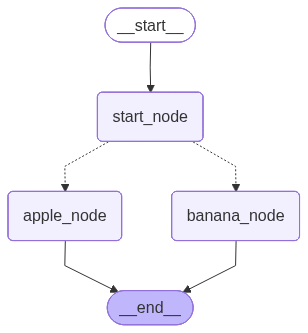

In [59]:
# Build Graph
graph = StateGraph(State)

# Adding the nodes
graph.add_node('start_node', start_node)
graph.add_node('apple_node', apple_node)
graph.add_node('banana_node', banana_node)

# Adding the edges
graph.add_edge(START, 'start_node')
graph.add_conditional_edges('start_node', random_node,)
graph.add_edge('apple_node', END)
graph.add_edge('banana_node', END)

# Compile the graph
graph_builder = graph.compile()

# View the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))



Invoke Graph

In [60]:
graph_builder.invoke({
    'graph_data': 'My name is Saheed '
})

Starting fruits node
Random fruit node executed
Banana node executed


{'graph_data': 'My name is Saheed I am ready to eat bunch of bananas.'}

In [61]:
# Example usage
final_state = graph_builder.invoke({
    'graph_data': 'My name is Saheed and I have a craving for ' # initial graph data
})
print(final_state['graph_data'])



Starting fruits node
Random fruit node executed
Banana node executed
My name is Saheed and I have a craving for I am ready to eat bunch of bananas.
